

$$
\begin{array}{c}
\textbf{CAUSAL INFERENCE (DS-UA 201)}\\\\
\textbf{Lab: Hypothesis Testing, Confidence Intervals, and Experiments} \\
\textit{Center for Data Science, New York University} \\\\
\end{array}
$$

---

Last week - how to compute **estimate**, like a sample mean, from data. Suppose a study reports that a job training program raised wages by \$1,200 a year. Two questions we will try to answer:

1. *Could that number just be luck?* Maybe the program does nothing and the people in this particular sample happened to earn a bit more. (**Hypothesis testing**)
2. *What range of effects is believable given the data?* (**Confidence intervals**)

And a third question from the course, is it causal? 

3. *Even if the number is not luck, is it really the **effect** of the program?* Maybe the people who signed up were different to begin with. (**Experiments**)

By the end of the lab you should be able to:
- explain what bias, variance and consistency mean for an estimator;
- run a two-sided test of a mean by hand and in Python, and explain what the p-value means;
- say what a significance level controls, and name the two kinds of error a test can make;
- build and correctly interpret a confidence interval;
- explain why randomizing treatment removes confounding.

## 0. Quick recap from last week (Statistics Review 1)

| Idea | One-line version |
|---|---|
| **Population / data-generating process** | The thing we want to learn about. It has fixed but unknown **parameters**, like the true mean $\mathbb{E}[X] = \mu$. |
| **Sample** | $n$ draws $X_1, \dots, X_n$ taken at random from the population. |
| **Estimator** | A *rule* that turns a sample into a guess, e.g. the sample mean $\overline{X}_n = \frac{1}{n}\sum_i X_i$. Because the sample is random, an estimator is a **random variable**. |
| **Estimate** | The *number* you get when you apply the rule to the one sample you actually have, e.g. $\bar{x} = 4.87$. |
| **Weak Law of Large Numbers (WLLN)** | As $n$ grows, $\overline{X}_n$ gets closer and closer to $\mu$. |
| **Central Limit Theorem (CLT)** | For large $n$, the *standardized error* of the sample mean looks like a standard normal: $\dfrac{\sqrt{n}}{\hat{\sigma}_n}\left(\overline{X}_n - \mu\right) \approx N(0,1)$. |

**Why the CLT matters in this lab:** it tells us the (approximate) distribution of the error (avg. = 0, std. dev = 1, and normal) in our estimate *without knowing anything else about the population*. Everything in this lab, including p-values, significance tests and confidence intervals, is built on that one fact.

### The Sampling Distribution

Example: 1,000 different research teams each go out and collect their own random sample of 100 NYU students and compute the average number of hours slept. They will not all get the same answer. If we plotted the 1,000 averages as a histogram, we would get the **sampling distribution** of the sample mean.

In real life you only ever see *one* of those 1,000 numbers: your own. Statistics lets us reason about the whole histogram from that single draw. The WLLN and CLT tell us what the histogram looks like:

- it is centred on the true mean $\mu$ (the sample mean is unbiased);
- its width shrinks like $\sigma / \sqrt{n}$ as the sample grows (the WLLN);
- its shape is approximately a bell curve (normal) (the CLT).

Once we know the shape and width of that histogram, we can say how far from the truth a typical estimate lands, and therefore how surprised we should be by any particular result.

### Setup
- `rng = np.random.default_rng(42)` creates a random-number generator with a fixed **seed**, so everyone in the room gets exactly the same "random" results. Change `42` to see different draws.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import scipy.stats as stats
import networkx as nx

BLUE, ORANGE, GREEN, GRAY = "#2a78d6", "#eb6834", "#1baf7a", "#8a8984"

plt.rcParams.update({
    "figure.figsize": (8, 4.5),
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.grid": True,
    "grid.alpha": 0.25,
    "font.size": 11,
})

# a seeded random-number generator makes every result reproducible
rng = np.random.default_rng(42)

## 1. Notes: bias, variance and consistency of an estimator

There are many possible estimators for the same parameter, so we need a way to judge them. Let $\hat{\theta}_n$ be an estimator of a parameter $\theta$ built from $n$ observations.

> **Intuition: throwing darts.** Think of the true parameter as the bullseye and each estimate as one dart, thrown by someone using a particular estimator. If you could watch them throw many darts (one per possible sample):
> - **Bias** is whether the darts are centred on the bullseye or systematically off to one side.
> - **Variance** is how tightly the darts cluster, wherever they are centred.
> - **Consistency** is whether the thrower gets steadily better as they are given more data, so that with enough data every dart lands on the bullseye.
>
> A thrower can be unbiased but imprecise (darts scattered all around the bullseye), or very precise but biased (a tight cluster in the wrong place). Ideally we want both low bias and low variance.

**Bias: is it right on average?**
$$\text{Bias}(\hat{\theta}_n) = \mathbb{E}[\hat{\theta}_n] - \theta$$
If we could repeat the sampling many times, would the estimates be centred on the truth? If the bias is $0$, the estimator is **unbiased**. The sample mean is unbiased for $\mu$.

**Variance: how much does it bounce around?**
$$\text{Var}(\hat{\theta}_n) = \mathbb{E}\big[(\hat{\theta}_n - \mathbb{E}[\hat{\theta}_n])^2\big]$$
Even an unbiased estimator can land far from the truth in any one sample. Lower variance means more precise estimates. For the sample mean, $\text{Var}(\overline{X}_n) = \sigma^2 / n$, so it shrinks as $n$ grows. Its square root, $\sigma/\sqrt{n}$, is the **standard error**.

**Consistency: does it get it right with enough data?**
$$\hat{\theta}_n \xrightarrow{p} \theta \quad \text{as } n \to \infty$$
As the sample grows, the estimator gets arbitrarily close to the truth with probability approaching one. The WLLN says exactly this for the sample mean. An important sufficient condition: *bias and variance both go to zero as $n$ grows.*

**Unbiased and consistent are different things.** Below we compare three estimators of the mean of a Uniform(0, 10) distribution (true mean $= 5$):

| Estimator | Formula | Unbiased? | Consistent? |
|---|---|---|---|
| Sample mean | $\frac{1}{n}\sum_i X_i$ | Yes | Yes |
| First observation only | $X_1$ | Yes | **No**: ignores the rest of the data, so its variance never shrinks |
| "Shrunk" mean | $\frac{1}{n+5}\sum_i X_i$ | **No**: pulled towards 0 | Yes: the bias vanishes as $n$ grows |

A useful summary of overall accuracy that combines both properties is the **mean squared error**: $\text{MSE} = \text{Bias}^2 + \text{Variance}$. It measures the average squared distance between an estimate and the truth, and the formula shows that you can be far from the truth either by being systematically off (bias) or by being noisy (variance).

**The code below (explanation)**
- `true_mean = 5` is the parameter we are trying to estimate.
- `estimators` is a dictionary that maps a name to a small function. Each function takes a `samples` array (one row per simulated sample) and returns one estimate per row.
- For each sample size `n` in `[5, 50, 500]` we draw `reps = 5000` separate samples with `rng.uniform(0, 10, size=(reps, n))`. Each row is one possible sample a researcher might have collected.
- We apply each estimator to all 5,000 samples at once and record the average bias, the variance and the MSE across those 5,000 estimates.
- `pd.DataFrame(rows)` collects the results into a table so we can compare them.

In [4]:
true_mean = 5
reps = 5000

# Each estimator takes a 2-D array (rows are samples) and returns one estimate per row.
estimators = {
    "Sample mean":        lambda s: s.mean(axis=1),
    "First observation":  lambda s: s[:, 0],
    "Shrunk mean":        lambda s: s.sum(axis=1) / (s.shape[1] + 5),
}

rows = []
for n in [5, 50, 500]:
    # 5,000 independent samples of size n from Uniform(0, 10).
    samples = rng.uniform(0, 10, size=(reps, n))
    for name, estimator in estimators.items():
        est = estimator(samples)
        rows.append({
            "estimator": name,
            "n": n,
            "bias": est.mean() - true_mean,
            "variance": est.var(),
            "MSE": ((est - true_mean) ** 2).mean(),
        })

table = pd.DataFrame(rows).round(3)

# Print one small table per quantity so nothing gets cut off.
for quantity in ["bias", "variance", "MSE"]:
    print(f"{quantity.upper()} (columns are sample sizes)")
    print(table.pivot(index="estimator", columns="n", values=quantity).to_string())
    print()

BIAS (columns are sample sizes)
n                    5      50     500
estimator                             
First observation  0.005 -0.003 -0.019
Sample mean        0.001  0.001 -0.001
Shrunk mean       -2.500 -0.454 -0.050

VARIANCE (columns are sample sizes)
n                    5      50     500
estimator                             
First observation  8.415  8.088  8.166
Sample mean        1.648  0.173  0.016
Shrunk mean        0.412  0.143  0.016

MSE (columns are sample sizes)
n                    5      50     500
estimator                             
First observation  8.415  8.088  8.167
Sample mean        1.648  0.173  0.016
Shrunk mean        6.660  0.349  0.018



- *Sample mean*: bias is about zero at every $n$ and the variance falls roughly tenfold each time $n$ grows tenfold. Unbiased **and** consistent.
- *First observation*: bias is about zero, but the variance stays around $8.3$ (the variance of a single Uniform(0, 10) draw) no matter how big $n$ gets. Unbiased but **not** consistent.
- *Shrunk mean*: clearly biased at $n=5$, but the bias and variance both melt away as $n$ grows. Biased but consistent.

Notice that at $n = 5$ the shrunk mean actually has a *smaller* variance than the sample mean (it squashes every estimate towards zero), but its bias is so large that its MSE is much worse. Low variance alone is not enough.

## 2. Sampling demo: how sample means behave

This section is a condensed version of the *Sampling and Sample Mean* notebook from Brightspace. 

We sample from a Uniform distribution on $[-5, 5]$, so every value between $-5$ and $5$ is equally likely and the true mean is $0$.

### 2a. Different samples give different estimates 

**Code explained**
- Draws 3 separate samples of size `n = 30`.
- Plots each sample as a row of dots, with the sample mean marked by a vertical orange line and the true mean (0) by a dashed black line.
- The point: the estimator (the rule "take the average") is the same every time, but the estimate changes from sample to sample. That randomness is what the rest of the lab is about.

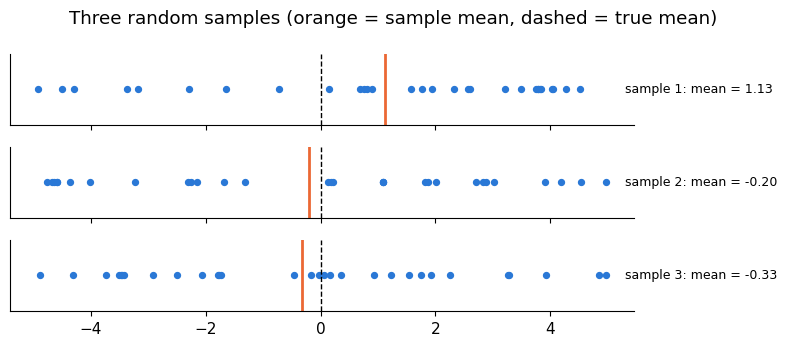

In [7]:
low, high = -5, 5        # Uniform(-5, 5), so the true mean is 0.
n = 30

fig, axes = plt.subplots(3, 1, figsize=(8, 3.5), sharex=True)
for i, ax in enumerate(axes):
    sample = rng.uniform(low, high, size=n)
    ax.scatter(sample, np.zeros(n), color=BLUE, s=18)
    ax.axvline(sample.mean(), color=ORANGE, linewidth=2) #orange line at sample mean 
    ax.axvline(0, color="black", linestyle="--", linewidth=1) # black dashed line at average = 0 (true mean)
    ax.set_yticks([])
    ax.grid(False)
    ax.text(5.3, 0, f"sample {i+1}: mean = {sample.mean():.2f}", va="center", fontsize=9)

fig.suptitle("Three random samples (orange = sample mean, dashed = true mean)")
fig.tight_layout()
plt.show()

The three samples come from exactly the same population, yet their means differ, some by a noticeable amount. None of them equals the true mean of $0$ exactly. This is **sampling variability**, and it is why a single estimate should never be taken at face value.

### 2b. Weak Law of Large Numbers: bigger samples, closer estimates

**Code explained**
- `sample_sizes = np.arange(1, 1001)` lists every sample size from 1 to 1,000.
- For each size we draw a fresh sample and store its mean in `means`.
- We plot the mean against the sample size. Early on (small $n$) the estimates jump around; as $n$ grows they settle down next to the true value of 0 -> consistency

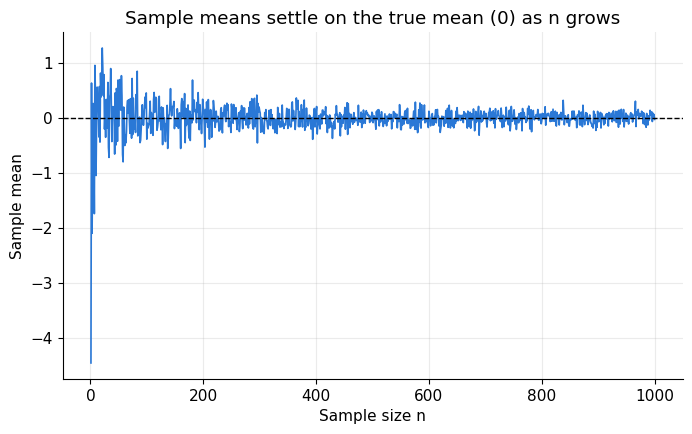

In [ ]:
sample_sizes = np.arange(1, 1001)
means = [rng.uniform(low, high, size=k).mean() for k in sample_sizes] #same uniform distribution as the last question

fig, ax = plt.subplots()
ax.plot(sample_sizes, means, color=BLUE, linewidth=1.2)
ax.axhline(0, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="Sample size n", ylabel="Sample mean",
       title="Sample means settle on the true mean (0) as n grows")
plt.show()

With only a handful of observations the sample mean can be off by 2 or more. By a few hundred observations it is rarely more than a few tenths away from 0. To halve the typical error you need four times as much data, because the standard error scales with $1/\sqrt{n}$, not $1/n$.

### 2c. Central Limit Theorem: the error in the sample mean is (approximately) normal

The WLLN says the error $\overline{X}_n - \mu$ shrinks. The CLT says something stronger: if we rescale the error by the standard error, its distribution settles into a fixed shape, the standard normal. The rescaled quantity is the standardized error:
$$Z = \frac{\sqrt{n}}{\hat{\sigma}_n}\left(\overline{X}_n - \mu\right) = \frac{\overline{X}_n - \mu}{\hat{\sigma}_n / \sqrt{n}}$$

*"How many standard errors is the estimate away from the truth?"* The CLT says this number has a distribution from $N(0, 1)$. So about 68% of the time it is between $-1$ and $1$, about 95% of the time between $-1.96$ and $1.96$, and it is almost never beyond $\pm 3$.

For each sample size below we draw 2,000 samples and compute $Z$ for each one.

**Code explained**
- `true_sd` is the true standard deviation of Uniform(-5, 5). We only need it for $n=1$, because you cannot compute a sample standard deviation from a single observation.
- For each `n` we draw a 2,000 × `n` array of samples. `.mean(axis=1)` gives 2,000 sample means and `.std(axis=1, ddof=1)` gives 2,000 sample standard deviations (`ddof=1` divides by $n-1$, the usual sample formula).
- We compute the standardized errors `z` and plot their histogram (`density=True` scales it so it is comparable with a probability density).
- The orange curve is the standard normal density, `stats.norm.pdf`. By around $n = 30$ the histogram matches it closely, even though the uniform distribution itself looks nothing like a bell curve.

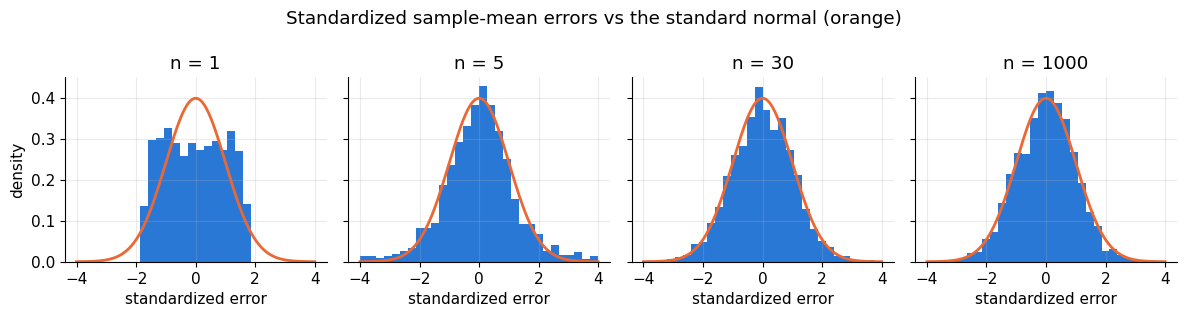

In [9]:
true_sd = (high - low) / np.sqrt(12)      # Standard deviation of a uniform distribution.
grid = np.linspace(-4, 4, 200)

fig, axes = plt.subplots(1, 4, figsize=(12, 3.2), sharey=True)
for ax, n in zip(axes, [1, 5, 30, 1000]):
    samples = rng.uniform(low, high, size=(2000, n))
    xbar = samples.mean(axis=1)
    sd_hat = true_sd if n == 1 else samples.std(axis=1, ddof=1)
    z = np.sqrt(n) * (xbar - 0) / sd_hat

    ax.hist(z, bins=30, range=(-4, 4), density=True, color=BLUE)
    ax.plot(grid, stats.norm.pdf(grid), color=ORANGE, linewidth=2)
    ax.set_title(f"n = {n}")
    ax.set_xlabel("standardized error")

axes[0].set_ylabel("density")
fig.suptitle("Standardized sample-mean errors vs the standard normal (orange)")
fig.tight_layout()
plt.show()


- At $n = 1$ the histogram is flat: it is just the uniform distribution itself, rescaled.
- At $n = 5$ it is already bell-shaped in the middle, though the tails are a bit too heavy (because $\hat{\sigma}_n$ is a poor estimate with only 5 points).
- By $n = 30$ and beyond, the histogram and the orange normal curve are more similar.

**Key points**
- Sample means vary from sample to sample; that variation is unavoidable.
- The size of the variation is measured by the standard error, which shrinks like $1/\sqrt{n}$.
- Measured in standard errors, the error of a sample mean is approximately standard normal. This is the ruler we will use to judge whether a result is "surprising".

## 3. Hypothesis testing

Because the CLT tells us how the error in $\overline{X}_n$ is distributed, we can ask: *if some claim about the population were true, how surprising would our data be?* If the answer is "very surprising", that is evidence against the claim.

> **Intuition: is this coin fair?** A friend flips a coin 10 times and gets 9 heads. *If* the coin were fair, 9 or more heads out of 10 would be really unusual (it happens about 1% of the time). So either something very unlikely happened, or the coin is not fair." That is a hypothesis test. The claim "the coin is fair" is the null hypothesis, and "about 1%" is the p-value.

> **Intuition: a courtroom.** A test works like a criminal trial.
> - The defendant is presumed innocent (the null hypothesis is assumed true).
> - The prosecution must bring evidence that would be very unlikely if the defendant were innocent (a small p-value).
> - If the evidence is strong enough, the verdict is guilty (reject $H_0$). Otherwise the verdict is not guilty (fail to reject $H_0$).
>
> Crucially, "not guilty" is not the same as "proven innocent". It only means the evidence was not strong enough. In the same way, failing to reject $H_0$ never proves $H_0$ is true.


- **Null hypothesis $H_0$**: the statement we are trying to find evidence *against*. In causal inference this is usually "the treatment has no effect" (e.g. ATE $= 0$).
- **Alternative hypothesis $H_1$**: what we would conclude if we reject $H_0$ (e.g. ATE $\neq 0$ (two-tailed) or greater than/less than (one-tailed)).
- **Test statistic $T_n$**: a number computed from the data, designed so that large values are unlikely if $H_0$ is true.

**Two-sided test of an expectation** (the case from the slides)
$$H_0: \mathbb{E}[X] = \mu_0 \qquad H_1: \mathbb{E}[X] \neq \mu_0$$
$$T_n = \frac{\sqrt{n}}{\hat{\sigma}_n}\,\big|\overline{X}_n - \mu_0\big|$$

In words: *how many standard errors is our estimate away from the hypothesized value?* If $H_0$ is true, the CLT says $\frac{\sqrt{n}}{\hat{\sigma}_n}(\overline{X}_n - \mu_0) \approx N(0,1)$, so $T_n$ is the absolute value of a standard normal. Values like $0.5$ or $1$ are completely ordinary; values like $4$ or $18$ almost never happen.

### The p-value 
$$\hat{p}_n = P\big(|N| \geq T_n\big) = 2\,\Phi(-T_n), \qquad N \sim N(0,1)$$
where $\Phi$ is the standard normal CDF. It answers: **if $H_0$ were true, how likely is a test statistic at least as large as the one we got?** Smaller p-value means the data are harder to reconcile with $H_0$, so stronger evidence against it.

The factor of 2 appears because the test is two-sided: we count surprises in both tails ($\overline{X}_n$ far *above* $\mu_0$ or far *below* it), and the normal is symmetric.

### Steps for a test

1. State the null and alternative. What claim are we testing?
2. Compute the estimate from the data (here, $\overline{X}_n$).
3. Measure the gap in standard errors: $T_n = |\text{estimate} - \text{null value}| \,/\, \text{standard error}$.
4. Convert to a p-value:how often would a gap this large happen by chance if the null were true?
5. Conclude in words, saying what the evidence does and does not show.

> Common mistake. The p-value is **not** "the probability that $H_0$ is true". It is calculated *assuming* $H_0$ is true, so it cannot tell you the probability of $H_0$ itself. The correct reading is: "*If* the null were true, data this extreme would show up $\hat{p}_n \times 100\%$ of the time."

### A picture of the p-value

**Code explained**
- Plots the standard normal density: the distribution of the signed statistic if $H_0$ is true.
- Picks an example statistic `T = 2.1` and shades the two tail areas beyond $-2.1$ and $+2.1$ in orange. The total shaded area **is** the p-value.
- `stats.norm.cdf(-T)` gives the area in the left tail, so `2 * stats.norm.cdf(-T)` is the two-sided p-value.

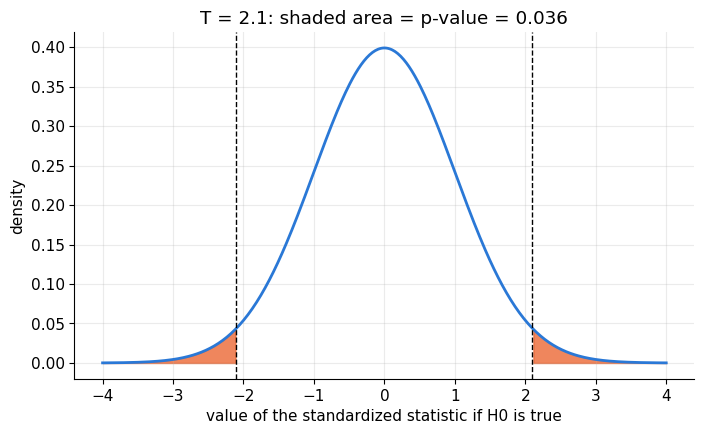

In [10]:
T = 2.1
p = 2 * stats.norm.cdf(-T)

x = np.linspace(-4, 4, 400)
fig, ax = plt.subplots()
ax.plot(x, stats.norm.pdf(x), color=BLUE, linewidth=2)
ax.fill_between(x, stats.norm.pdf(x), where=(x >= T), color=ORANGE, alpha=0.8)
ax.fill_between(x, stats.norm.pdf(x), where=(x <= -T), color=ORANGE, alpha=0.8)
ax.axvline(T, color="black", linestyle="--", linewidth=1)
ax.axvline(-T, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="value of the standardized statistic if H0 is true", ylabel="density",
       title=f"T = {T}: shaded area = p-value = {p:.3f}")
plt.show()

The blue curve is what the standardized statistic looks like when the null is true. A statistic of $2.1$ sits out in the tails: only about 3.6% of the curve's area lies beyond $\pm 2.1$. Try changing `T` to `0.5` and to `3.5` and re-run. At $0.5$ most of the curve is shaded (a completely expected result); at $3.5$ almost none of it is (a very surprising result under $H_0$).

### Worked example: computing $T_n$ and the p-value step by step

Suppose we collect $n = 50$ observations and want to test $H_0: \mathbb{E}[X] = 5$. (We secretly generate the data with a true mean of $5.4$, so $H_0$ is actually false here, but in real life you would not know that.)

**Code Explained**
1. `rng.normal(loc=5.4, scale=1.5, size=50)` simulates the data.
2. Computes the three ingredients of $T_n$: sample size `n`, sample mean `xbar`, and sample standard deviation `sd_hat` (`ddof=1` for the $n-1$ version).
3. `se = sd_hat / np.sqrt(n)` is the standard error, the estimated standard deviation of $\overline{X}_n$.
4. `T_n = abs(xbar - mu_0) / se` is the test statistic from the slides (dividing by $\hat{\sigma}_n/\sqrt{n}$ is the same as multiplying by $\sqrt{n}/\hat{\sigma}_n$).
5. `p_value = 2 * stats.norm.cdf(-T_n)` is the two-sided p-value.

In [ ]:
data = rng.normal(loc=5.4, scale=1.5, size=50) #random number generator from normal dist 
mu_0 = 5                                  # The value claimed by the null hypothesis.

n = len(data)
xbar = data.mean()
sd_hat = data.std(ddof=1)
se = sd_hat / np.sqrt(n)                  # Standard error of the sample mean.

T_n = abs(xbar - mu_0) / se               # How many standard errors from mu_0?
p_value = 2 * stats.norm.cdf(-T_n)        # Two-sided p-value from the normal.

print(f"n = {n}, sample mean = {xbar:.3f}, sample sd = {sd_hat:.3f}, standard error = {se:.3f}")
print(f"T_n = {T_n:.3f}")
print(f"p-value = {p_value:.4f}")

n = 50, sample mean = 5.215, sample sd = 1.555, standard error = 0.220
T_n = 0.976
p-value = 0.3293


**Reading the output**
- The sample mean is about $5.22$, which is $0.22$ above the null value of $5$.
- The standard error is also about $0.22$: a typical sample of 50 lands about $0.22$ away from the true mean just by chance.
- So the gap between the sample mean and null is about one standard error ($T_n \approx 0.98$). 
- The p-value of about $0.33$ says: *if the true mean really were 5, we would see a sample mean at least this far from 5 about a third of the time.* So we **do not reject** $H_0$ as the p-value is not small enough.

 We generated the data with a true mean of $5.4$, so $H_0$ is actually false. The test missed it, because with only 50 noisy observations, a true difference of $0.4$ is hard to tell apart from chance. Missing a real effect like this is called a **Type II error**, and it is why "we failed to reject" must never be read as "we proved there is no difference". We come back to this in Section 4 and in Exercise 4.

### Coding the test into a function

We will reuse this test several times.

**Code Explained**
- `two_sided_test(data, mu_0)` repeats the steps above and returns both $T_n$ and the p-value.
- We then call it for two different nulls. $\mu_0 = 5$ is fairly close to the sample mean, so the p-value is moderate. $\mu_0 = 8$ is far away, so the p-value is essentially $0$.

In [13]:
def two_sided_test(data, mu_0): #using same random generated data from above
    # Test H0: E[X] = mu_0 against H1: E[X] != mu_0 using the CLT approximation.
    n = len(data)
    se = data.std(ddof=1) / np.sqrt(n)
    T_n = abs(data.mean() - mu_0) / se
    p_value = 2 * stats.norm.cdf(-T_n)
    return T_n, p_value

for mu_0 in [5, 8]:
    T_n, p_value = two_sided_test(data, mu_0)
    print(f"H0: E[X] = {mu_0}:  T_n = {T_n:6.2f},  p-value = {p_value:.4g}")

H0: E[X] = 5:  T_n =   0.98,  p-value = 0.3293
H0: E[X] = 8:  T_n =  12.66,  p-value = 9.45e-37


Same data, different nulls, very different conclusions. The value $8$ is almost 13 standard errors away from the sample mean, and a gap that large essentially never happens by chance, so the p-value is tiny and we reject $H_0: \mathbb{E}[X] = 8$ with confidence. A test is always a statement about a specific null value.

### Checking against SciPy

`scipy.stats.ttest_1samp(data, popmean=mu_0)` runs the same test in one line.

Two small differences from our hand-made version:
- SciPy reports the **signed** statistic, $(\overline{X}_n - \mu_0)/\text{se}$, so it can be negative. Its absolute value equals our $T_n$.
- SciPy uses the $t$ distribution with $n-1$ degrees of freedom instead of the normal, which gives a slightly larger p-value in small samples. For large $n$ the two are practically identical.

In [14]:
result = stats.ttest_1samp(data, popmean=5)
print(result)
print(f"Our normal-based p-value: {two_sided_test(data, 5)[1]:.4f}")

TtestResult(statistic=0.9755190334634988, pvalue=0.3340944733150365, df=49)
Our normal-based p-value: 0.3293


**SciPy's output**
- `statistic` is the signed $t$-statistic: positive here because the sample mean is above $5$.
- `pvalue` is the two-sided p-value ($0.334$, very close to our $0.329$).
- `df` is the degrees of freedom, $n - 1 = 49$, used by the $t$ distribution.

> If we collected 4 times as much data and the sample mean stayed at exactly 5.22, roughly what would happen to $T_n$?
>
> <details><summary>Answer</summary>
>
> The standard error would halve (it scales with $1/\sqrt{n}$ and $\sqrt{4} = 2$), so $T_n$ would roughly double to about 2. The p-value would drop to around 0.05. The same gap becomes more convincing when it is measured more precisely.
> </details>

**Key point**
- A test asks: how many standard errors is the estimate from the null value, and how often would a gap that large happen by chance?
- Small p-value: the data are hard to explain if $H_0$ is true. Large p-value: the data are compatible with $H_0$ (but also possibly with other values).
- A p-value is computed *assuming* $H_0$; it is not the probability that $H_0$ is true.

## 4. Significance levels, Type I and Type II errors

A p-value is a *continuous* measure of evidence. To make a yes/no decision we pick a **significance level** $\alpha$ before looking at the data (common choices: $0.10$, $0.05$, $0.01$).

> **Decision rule:** reject $H_0$ if $\hat{p}_n < \alpha$. Equivalently, reject if $T_n > c$, where the **critical value** $c = \Phi^{-1}(1 - \alpha/2)$. For $\alpha = 0.05$, $c \approx 1.96$.

A result significant at level $\alpha$ is also significant at any *larger* level: if $p < 0.01$ then certainly $p < 0.05$.

**Errors in Testing**

| | $H_0$ is true | $H_0$ is false |
|---|---|---|
| **Reject $H_0$** | **Type I error** (false positive) | Correct |
| **Do not reject $H_0$** | Correct | **Type II error** (false negative) |

> **Intuition: a smoke alarm.** A Type I error is the alarm going off when there is no fire (a false alarm). A Type II error is the alarm staying silent during a real fire (a missed detection - more concerning). Making the alarm less sensitive (a smaller $\alpha$) means fewer false alarms but more missed fires. You cannot push both errors to zero at once with a fixed amount of data; the only way to reduce both is a better detector, which in statistics usually means **more data**.

The significance level is exactly the Type I error rate we are willing to accept: if $H_0$ is true, a test at $\alpha = 0.05$ rejects it 5% of the time purely by chance. The framework says nothing directly about Type II error; that depends on sample size and how far the truth is from $\mu_0$.

Four nulls, each "ATE $= 0$" for a different treatment:

| Null | p-value |
|---|---|
| ATE$_a = 0$ | 0.10 |
| ATE$_b = 0$ | 0.01 |
| ATE$_c = 0$ | 0.90 |
| ATE$_d = 0$ | 0.09 |

Which ATE has the strongest evidence of being non-zero? Which has the weakest?
>
> <details><summary>Answer</summary>
>
> Strongest: **b** (smallest p-value, 0.01). Weakest: **c** (p = 0.90). Note that $c$'s large p-value does *not* show that the ATE is zero; it only shows the data give no strong evidence against zero. Also note that **a** and **d** (p = 0.10 and 0.09) carry almost identical evidence, even though only **d** clears a 0.10 threshold.
> </details>

**Code Explained**
- `stats.norm.ppf(1 - alpha / 2)` is the inverse normal CDF, $\Phi^{-1}$. It returns the cut-off $c$ that leaves $\alpha/2$ in each tail.
- The loop prints the critical value for the three common significance levels.

In [15]:
for alpha in [0.10, 0.05, 0.01]:
    c = stats.norm.ppf(1 - alpha / 2)
    print(f"alpha = {alpha:.2f}: reject H0 when T_n > {c:.3f}")

alpha = 0.10: reject H0 when T_n > 1.645
alpha = 0.05: reject H0 when T_n > 1.960
alpha = 0.01: reject H0 when T_n > 2.576


 A stricter test (smaller $\alpha$) demands a bigger gap before it rejects: 1.64 standard errors at the 10% level, 1.96 at 5%, and 2.58 at 1%. The common "1.96" is simply the point that leaves 2.5% of the standard normal in each tail. In the worked example above, $T_n \approx 0.98$ is below all three cut-offs, so we would not reject at any of these levels.

### Simulation: when $H_0$ is true, we still reject 5% of the time

**What the code does**
- Simulates 10,000 separate studies, each with $n = 200$ observations. In **every one**, the null is true: mean = $5$ and we test $H_0: \mathbb{E}[X] = 5$.
- Stores each study's p-value, then computes the share that fall below $0.05$, which is the false-positive (Type I error) rate.
- Plots a histogram of the 10,000 p-values. When $H_0$ is true, p-values are spread **evenly** between 0 and 1. The bars to the left of the dashed line at $0.05$ are the false positives, about 5% of all studies.

Share of studies with p < 0.05 when H0 is TRUE: 0.052


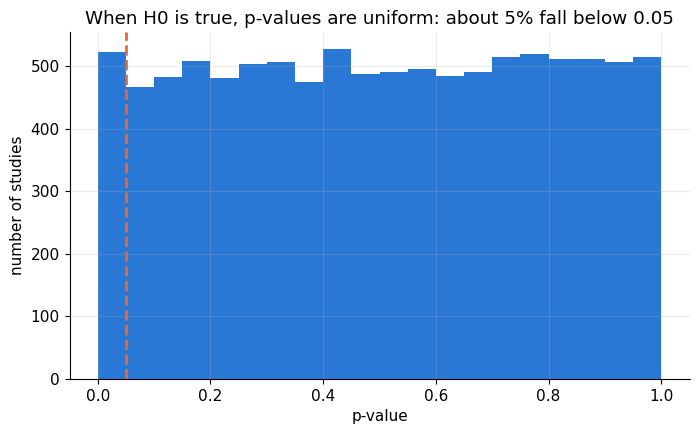

In [16]:
n_studies = 10_000
null_pvalues = np.array([
    two_sided_test(rng.normal(5, 1.5, size=200), mu_0=5)[1]
    for _ in range(n_studies)
])

print(f"Share of studies with p < 0.05 when H0 is TRUE: {(null_pvalues < 0.05).mean():.3f}")

fig, ax = plt.subplots()
ax.hist(null_pvalues, bins=20, range=(0, 1), color=BLUE)
ax.axvline(0.05, color=ORANGE, linestyle="--", linewidth=2)
ax.set(xlabel="p-value", ylabel="number of studies",
       title="When H0 is true, p-values are uniform: about 5% fall below 0.05")
plt.show()

Even though the null is true in every single study, about 5% of them still produce $p < 0.05$ and would be reported as "significant". Those are pure false alarms. This is exactly the error rate we agreed to when we chose $\alpha = 0.05$.

### P-values and significance are not everything

1. Thresholds are arbitrary. With $\alpha = 0.05$, $p = 0.049$ is "significant" and $p = 0.051$ is not, even though the evidence is essentially identical.
2. "Not significant" does not mean "no effect". A large p-value only says we lack strong evidence *against* $H_0$. Maybe the sample is small or the data are noisy. Absence of evidence is not evidence of absence. Confidence intervals (next section) help here.
3. "Significant" does not mean "important". With a huge sample, a tiny and practically meaningless effect can have a very small p-value. Always look at the size of the estimate too.
4. Run enough tests and something will be significant. At $\alpha = 0.05$, one in twenty true nulls is rejected by chance. 


**Key points**
- Choose $\alpha$ before looking at the data. It is the false-alarm rate you accept when $H_0$ is true.
- Type I error: rejecting a true null. Type II error: failing to reject a false null. Lowering one tends to raise the other unless you get more data.
- A p-value is not a measure of importance, "not significant" is not proof of no effect, and many tests produce false alarms by chance.

## 5. Confidence intervals

Hypothesis testing focuses on rejecting one particular value. Often we would rather ask: **which values of the parameter are consistent with the data?** That is what a confidence interval gives us.

> **Intuition: casting a net.** A point estimate is like fishing with a spear: you aim at one exact spot, and you will almost certainly miss the fish by a little. A confidence interval is like casting a net around your best guess. The net's width is set so that, if you cast it again and again on new samples, it catches the fish 95% of the time. The fish (the true mean) does not move; it is the net that moves from sample to sample.

A $(1-\alpha)$ **confidence interval** $C_n$ is a range computed from the data such that
$$P(\theta \in C_n) \approx 1 - \alpha.$$

Imagine running the two-sided test $H_0: \mathbb{E}[X] = \mu_0$ at level $\alpha$ for *every* possible $\mu_0$, and keeping all the values we fail to reject. That set is the confidence interval. When we happen to test the true mean, we wrongly reject it only $\alpha$ of the time, so the interval contains the truth $1-\alpha$ of the time. The endpoints are the most extreme $\mu_0$ values that are *just* not rejected:
$$C_n = \left[\,\overline{X}_n - c\,\frac{\hat{\sigma}_n}{\sqrt{n}},\;\; \overline{X}_n + c\,\frac{\hat{\sigma}_n}{\sqrt{n}}\,\right], \qquad c = \Phi^{-1}(1 - \alpha/2).$$

In words: **estimate ± critical value × standard error.** For a 95% interval that is estimate ± 1.96 standard errors.

**Interpretation.** The method captures the true mean in 95% of samples. For any one interval, the truth is either inside or not; the "95%" describes how reliable the method is across repeated samples.

> **Common mistake.** "There is a 95% probability that the true mean is between 4.78 and 5.65." Strictly, this is not right in the framework we are using: the true mean is a fixed number, not a random one, so once the interval is computed it either contains it or it does not. The safer phrasing is: "We are 95% confident the true mean is between 4.78 and 5.65, meaning this interval came from a method that captures the true mean in 95% of samples."

**What makes an interval wider or narrower?** Look at the half-width $c \cdot \hat{\sigma}_n / \sqrt{n}$:
- **More data** (larger $n$) makes it narrower.
- **Noisier data** (larger $\hat{\sigma}_n$) makes it wider.
- **More confidence** (99% instead of 95%, so a larger $c$) makes it wider. A net that catches the fish more often has to be bigger.

**Code Explained**
- `ci_mean(data, alpha)` computes the sample mean, the standard error and the critical value, then returns the lower and upper endpoints.
- `stats.norm.interval(confidence, loc, scale)` is SciPy's shortcut for the same thing: `loc` is the centre (the sample mean) and `scale` is the standard error. `stats.sem(data)` computes the standard error of the mean directly.
- The final lines check the test/interval duality: $\mu_0 = 5$ lies inside the 95% interval exactly when the level-0.05 test does *not* reject it.

In [17]:
def ci_mean(data, alpha=0.05):
    # Estimate plus or minus critical value times standard error.
    xbar = data.mean()
    se = data.std(ddof=1) / np.sqrt(len(data))
    c = stats.norm.ppf(1 - alpha / 2)
    return xbar - c * se, xbar + c * se

lo, hi = ci_mean(data)
print(f"Our 95% CI:   ({lo:.3f}, {hi:.3f})")

lo_sp, hi_sp = stats.norm.interval(0.95, loc=data.mean(), scale=stats.sem(data))
print(f"SciPy 95% CI: ({lo_sp:.3f}, {hi_sp:.3f})")

print(f"Is 5 inside the CI? {lo <= 5 <= hi}.  Test of H0: E[X] = 5 gives p = {two_sided_test(data, 5)[1]:.3f}")

Our 95% CI:   (4.783, 5.646)
SciPy 95% CI: (4.783, 5.646)
Is 5 inside the CI? True.  Test of H0: E[X] = 5 gives p = 0.329


**Math & the output** With the same data as the worked example, $\overline{X}_n \approx 5.215$ and $\text{se} \approx 0.220$:
$$5.215 \pm 1.96 \times 0.220 = 5.215 \pm 0.431 = (4.78,\ 5.65).$$

Every value in that range, including $5$ and the true value $5.4$, is consistent with the data at the 5% level. This is more informative than the test alone. The test only told us "we cannot rule out 5". The interval tells us we also cannot rule out anything from about 4.8 to 5.6, which makes it clear that the data are simply not precise enough to pin the mean down.

### Simulation: what "95% confidence" means

**Code Explained**
- Draws 100 separate samples of size 40 from a population whose true mean is $5$.
- Builds a 95% confidence interval from each sample and draws it as a horizontal line.
- Intervals that contain the true mean are blue; the few that miss it are orange. Across many samples, about 95% should be blue. Re-run the cell a few times and count the orange ones.

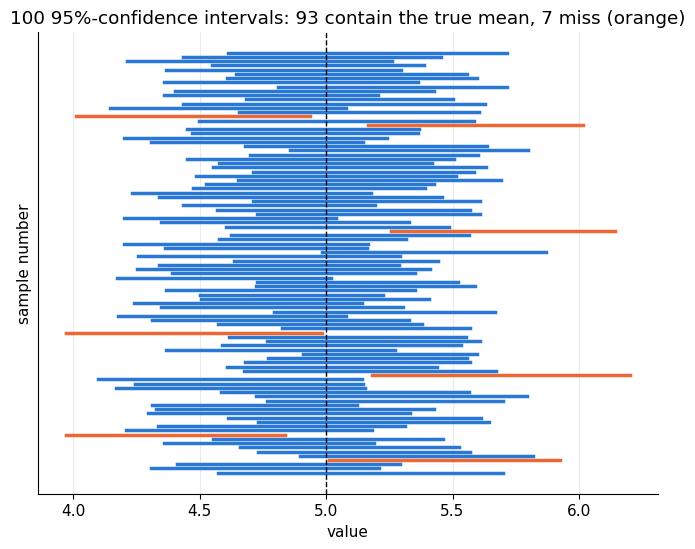

In [21]:
true_mu, n_intervals = 5, 100

fig, ax = plt.subplots(figsize=(8, 6))
misses = 0
for i in range(n_intervals):
    lo, hi = ci_mean(rng.normal(true_mu, 1.5, size=40))
    covers = lo <= true_mu <= hi
    misses += not covers
    ax.plot([lo, hi], [i, i], color=BLUE if covers else ORANGE, linewidth=2.5)

ax.axvline(true_mu, color="black", linestyle="--", linewidth=1)
ax.set(xlabel="value", ylabel="sample number", yticks=[],
       title=f"100 95%-confidence intervals: {n_intervals - misses} contain the true mean, {misses} miss (orange)")
plt.show()

- Each line is one researcher's interval from their own sample. They are centred in different places because the sample means differ.
- Most intervals cross the dashed true mean. A few (orange) miss it entirely, and those researchers have no way of knowing their interval is one of the unlucky ones.
- Out of 50 intervals we expect about $50 \times 0.05 = 2.5$ misses. Re-run the cell and the count will change, but on average it stays near 5%.

**Key points**
- A confidence interval is estimate ± critical value × standard error.
- It contains every null value that a two-sided test would *not* reject. Test and interval always agree.
- The interval shows both the direction and the size of the uncertainty, which a p-value alone does not.

## 6. Example: was there a "Covid crime wave"?

This follows the example from lecture, and it is a chance to run through the full code on data that looks like the real thing. In 2022 there were many news stories about rising violent crime during Covid. Headlines are one thing; can we find statistical evidence that the crime rate changed?

The National Crime Victimization Survey (NCVS) asks a random sample of Americans whether they were victims of a violent crime. Because it is a *survey of people* rather than a count of crimes reported to police, it also picks up crimes that were never reported.

- In 2018, the last fully pre-Covid year, the violent victimization rate was **0.0232** (23.2 per 1,000 people). As in lecture, we pretend this is known exactly.
- In the 2022 survey, $n = 226{,}962$ people responded, and the sample share of victims was about **0.0299**.

The cell below builds a stand-in data set with the same number of respondents and the same victimization rate, which reproduces the numbers on the slides. As in lecture, this is a quick illustration of the tools.

**Hypotheses**
$$H_0: \mathbb{E}[\text{victim}] = 0.0232 \quad (\text{same rate as 2018}) \qquad H_1: \mathbb{E}[\text{victim}] \neq 0.0232$$

**What the code does**
- Builds a stand-in table with one column `victim` that is 1 for victims and 0 for everyone else. The stand-in has exactly the lecture's number of respondents and victims, so the test results match the slides; `rng.permutation` just shuffles the order of the rows.
- `crime_d["victim"].mean()` is the sample share of victims, which is an estimate of the victimization rate.

In [22]:
USE_REAL_DATA = False

if USE_REAL_DATA:
    crime_d = pd.read_csv("crime_data_22.csv")
else:
    # Build a column with exactly as many victims as the lecture sample (0.02986 of 226,962),
    # then shuffle the rows into a random order.
    n_resp = 226_962
    victim = np.zeros(n_resp, dtype=int)
    victim[: round(0.02986 * n_resp)] = 1
    crime_d = pd.DataFrame({"victim": rng.permutation(victim)})

print(f"Number of respondents: {len(crime_d):,}")
print(f"Sample victimization rate in 2022: {crime_d['victim'].mean():.5f}")

Number of respondents: 226,962
Sample victimization rate in 2022: 0.02986


**Step 2: the estimate.** The sample rate of about $0.0299$ is clearly higher than $0.0232$. But on its own that proves nothing, the question is whether a gap of $0.0067$ is large relative to how much the sample mean typically wobbles with this many respondents.

A useful detail: `victim` is a 0/1 variable, so its mean is simply the share (%) of people who are victims. Everything we did for means works for proportions too.

**Steps 3 and 4: test statistic and p-value.**

**Code Explained**
- `stats.ttest_1samp(crime_d["victim"], popmean=0.0232)` tests whether the 2022 mean equals the 2018 rate.
- We also run our own `two_sided_test` to confirm it gives the same statistic.

In [23]:
print(stats.ttest_1samp(crime_d["victim"], popmean=0.0232))

T_n, p_value = two_sided_test(crime_d["victim"].to_numpy(), mu_0=0.0232)
print(f"Our version: T_n = {T_n:.2f}, p-value = {p_value:.3g}")

TtestResult(statistic=18.640857016448074, pvalue=1.7124085375870714e-77, df=226961)
Our version: T_n = 18.64, p-value = 1.5e-77


**Step 5: interpretation.** $T_n \approx 18.6$: the 2022 sample mean is about 18.6 standard errors above the 2018 rate. Under $H_0$, $T_n$ behaves like the absolute value of a standard normal, and a value that large is extremely unlikely, so the p-value is essentially 0. We reject $H_0$ at any conventional significance level. The difference is very unlikely to be a fluke of sampling.

Now the confidence interval, to see which rates are consistent with the data.

**Code Explained**
- `samp_mean` is the sample victimization rate.
- `stats.sem(...)` is the standard error of the mean, the "scale factor" from lecture.
- `stats.norm.interval(confidence=0.95, ...)` returns the 95% interval.

In [24]:
samp_mean = crime_d["victim"].mean()
scale_f = stats.sem(crime_d["victim"])

lo, hi = stats.norm.interval(confidence=0.95, loc=samp_mean, scale=scale_f)
print(f"95% CI for the 2022 victimization rate: ({lo:.4f}, {hi:.4f})")

95% CI for the 2022 victimization rate: (0.0292, 0.0306)


**Interpretation.** The interval is roughly $(0.029, 0.031)$: rates around 29 to 31 per 1,000 people are consistent with the 2022 data. The 2018 value of $0.0232$ is far outside it, which matches the test's conclusion. The interval also shows the size of the change (roughly 6 to 7 extra victims per 1,000 people), which the p-value alone does not.

**Why is the standard error so small?** With over 226,000 respondents, the standard error is only about $0.00036$. A huge sample measures the rate very precisely, so even a modest change stands out clearly. The flip side, from Section 4: with samples this big, even a *tiny* change would be "significant", which is why we look at the size of the change (the interval), not just the p-value.

This is statistical evidence that the 2022 rate differs from the 2018 figure. It does **not** tell us:
- that Covid **caused** the change (many other things also changed between 2018 and 2022);
- whether the survey methods were identical in both years;
- anything about individual cities, such as New York.

The first point is the big one: this is a statistical, not a causal, statement. It says the rate changed, not *why* it changed. That brings us to experiments - the randomization section from last week's notebook.

**Key points**
- The same recipe (estimate, standard error, test statistic, p-value, interval) works on real survey data, including 0/1 outcomes.
- Very large samples give very small standard errors, so always report the size of the effect alongside the p-value.

## Summary: today's toolkit on one page

| Concept | Formula or rule | In one sentence |
|---|---|---|
| Bias | $\mathbb{E}[\hat{\theta}_n] - \theta$ | Is the estimator right on average? |
| Variance / standard error | $\text{Var}(\overline{X}_n) = \sigma^2/n$, se $= \hat{\sigma}_n/\sqrt{n}$ | How much does the estimate wobble from sample to sample? |
| Consistency | $\hat{\theta}_n \to \theta$ as $n \to \infty$ | Does it get it right with enough data? |
| Test statistic | $T_n = \lvert\overline{X}_n - \mu_0\rvert / \text{se}$ | How many standard errors is the estimate from the null value? |
| p-value | $2\,\Phi(-T_n)$ | If $H_0$ were true, how often would we see a gap this large? |
| Significance level $\alpha$ | reject if $p < \alpha$, i.e. $T_n > \Phi^{-1}(1-\alpha/2)$ | The false-alarm rate we accept when $H_0$ is true. |
| Type I / Type II error | | Rejecting a true null / missing a false one. |
| Confidence interval | $\overline{X}_n \pm \Phi^{-1}(1-\alpha/2) \cdot \text{se}$ | The values not rejected by the test; captures the truth in $(1-\alpha)$ of samples. |
| Selection bias | $\mathbb{E}[Y(0)\mid S=1] - \mathbb{E}[Y(0)\mid S=0]$ | Did the groups differ before treatment? Randomization makes this zero. |

---

## 8. Exercises

Exercises 1 to 3 can be done on paper; the others use the code above as a starting point. Each code cell has `...` placeholders for you to fill in.

---

**Exercise 1: Is the sample median a good estimator of the mean?**
For a symmetric distribution like Uniform(0, 10), the median equals the mean. Add `"Sample median": lambda s: np.median(s, axis=1)` to the `estimators` dictionary in Section 1 and re-run the table.
- (a) Is the sample median biased? Is it consistent?
- (b) Compare its variance with the sample mean's. Which would you rather use, and why?
- (c) *Bonus:* would your answer to (a) change for a skewed distribution, such as `rng.exponential(5, size=(reps, n))`? Try it.

In [ ]:
# Exercise 1: add the median to the estimators and re-run the Section 1 table.
estimators["Sample median"] = ...

<details><summary><b>Show answer to Exercise 1</b></summary>

```python
estimators["Sample median"] = lambda s: np.median(s, axis=1)
```
Then re-run the two Section 1 cells that build and print the table.

**(a)** For Uniform(0, 10) the sample median is centred on 5 at every sample size (bias about 0), and its variance shrinks as $n$ grows (roughly 3.5 at $n = 5$, 0.47 at $n = 50$, 0.05 at $n = 500$). So it is unbiased and consistent for the mean.

**(b)** Its variance is about three times the sample mean's at every $n$ (e.g. 0.47 vs 0.17 at $n = 50$). Both hit the target on average, but the sample mean wobbles less, so it has the lower MSE and is the better choice here. The median only uses the middle of the data, while the mean uses every observation.

**(c)** Yes. The exponential distribution with mean 5 is skewed, and its median is $5 \ln 2 \approx 3.47$, not 5. The sample median converges to 3.47, so as an estimator of the mean it is biased (bias about $-1.5$ for large $n$) and not consistent: more data just makes it more precisely wrong. The sample mean is still unbiased and consistent. Swap the draw to `rng.exponential(5, size=(reps, n))` to see it.
</details>

**Exercise 2: A p-value by hand.**
A sample of $n = 36$ students has an average of $10.4$ hours of study per week, with sample standard deviation $\hat{\sigma}_n = 3$. Test $H_0: \mathbb{E}[X] = 10$ against a two-sided alternative.
- (a) Compute the standard error and $T_n$ by hand.
- (b) Use the code cell below to get the p-value. Do you reject $H_0$ at $\alpha = 0.05$?
- (c)"The p-value is big, so we've shown the true mean is 10." What is wrong with this statement?

In [ ]:
# Exercise 2: fill in the numbers, then compute the p-value.
n, xbar, sd_hat, mu_0 = ..., ..., ..., ...
se = ...
T_n = ...
p_value = 2 * stats.norm.cdf(-T_n)
print(T_n, p_value)

<details><summary><b>Show answer to Exercise 2</b></summary>

**(a)** $\text{se} = \hat{\sigma}_n / \sqrt{n} = 3 / \sqrt{36} = 3 / 6 = 0.5$.
$T_n = |10.4 - 10| / 0.5 = 0.4 / 0.5 = 0.8$.

**(b)**
```python
n, xbar, sd_hat, mu_0 = 36, 10.4, 3, 10
se = sd_hat / np.sqrt(n)
T_n = abs(xbar - mu_0) / se
p_value = 2 * stats.norm.cdf(-T_n)
print(T_n, p_value)   # 0.8, about 0.424
```
The p-value is about **0.42**, far above 0.05, so we **do not reject** $H_0$. 

**(c)** Failing to reject is not the same as proving $H_0$ ("not guilty" is not "innocent"). The data are also consistent with many other values: the 95% interval is $10.4 \pm 1.96 \times 0.5 = (9.42,\ 11.38)$, so a true mean of 9.5 or 11 fits the data just as well as 10. We lack the precision to rule them out.
</details>

**Exercise 3: Significance levels.**
Using the table of four ATEs from Section 4 (p-values 0.10, 0.01, 0.90, 0.09):
- (a) Which nulls are rejected at $\alpha = 0.10$? At $\alpha = 0.05$? At $\alpha = 0.01$?
- (b) Why can a result never be significant at $\alpha = 0.01$ but *not* at $\alpha = 0.05$?
- (c) Before seeing the data, a researcher picks $\alpha = 0.01$ instead of $0.05$. What happens to the Type I error rate? What do you expect to happen to the Type II error rate?

<details><summary><b>Show answer to Exercise 3</b></summary>

**(a)** Using the rule "reject if $p < \alpha$":
- $\alpha = 0.10$: reject **b** (0.01) and **d** (0.09). **a** has $p = 0.10$, which sits exactly on the boundary; with a strict "$<$" it is not rejected.
- $\alpha = 0.05$: reject **b** only.
- $\alpha = 0.01$: none are rejected. **b** has $p = 0.01$, exactly on the boundary.

Boundary cases like **a** and **b** are a good reminder that the thresholds are arbitrary: $p = 0.10$ and $p = 0.09$ carry essentially the same evidence.

**(b)** Being significant at 0.01 means $p < 0.01$, and any number below 0.01 is also below 0.05. So a result significant at a strict level is automatically significant at every looser level. The reverse is not true.

**(c)** The Type I error rate falls from 5% to 1%, because $\alpha$ *is* the false-alarm rate when $H_0$ is true. The Type II error rate goes up: the test now needs a bigger gap (2.58 standard errors instead of 1.96) before it rejects, so it misses more real effects. With the same amount of data, you cannot lower one error without raising the other (the smoke alarm trade-off).
</details>

**Exercise 4: Type II error and power.**
Suppose the true mean is $5.4$ and we test $H_0: \mathbb{E}[X] = 5$ at $\alpha = 0.05$, with data drawn as `rng.normal(5.4, 1.5, size=n)`. Here $H_0$ is **false**, so failing to reject is a Type II error.
- (a) Simulate 2,000 studies for each of $n = 20, 50, 200$. What share of studies rejects $H_0$? (This share is called the **power** of the test.)
- (b) What is the Type II error rate at each $n$?
- (c) In one sentence: why does a larger sample help?

In [ ]:
# Exercise 4: estimate the power of the test for several sample sizes.
for n in [20, 50, 200]:
    pvals = np.array([two_sided_test(..., mu_0=5)[1] for _ in range(2000)])
    power = ...
    print(f"n = {n}: power = {power:.3f}, Type II error rate = {1 - power:.3f}")

<details><summary><b>Show answer to Exercise 4</b></summary>

```python
for n in [20, 50, 200]:
    pvals = np.array([two_sided_test(rng.normal(5.4, 1.5, size=n), mu_0=5)[1] for _ in range(2000)])
    power = (pvals < 0.05).mean()
    print(f"n = {n}: power = {power:.3f}, Type II error rate = {1 - power:.3f}")
```

**(a)** Your exact numbers will vary slightly, but roughly:

| $n$ | Power | Type II error rate |
|---|---|---|
| 20 | about 0.24 | about 0.76 |
| 50 | about 0.47 | about 0.53 |
| 200 | about 0.96 | about 0.04 |

**(b)** The Type II error rate is $1 - \text{power}$ (the right-hand column). With 20 observations the test misses the real effect about three times out of four. With 50, it is roughly a coin flip, which is why the worked example in Section 3 failed to reject.

**(c)** A larger sample shrinks the standard error, so the same true gap of 0.4 becomes more standard errors wide and is much harder to mistake for chance.
</details>

**Exercise 5: Confidence intervals for the crime data.**
- (a) Compute the 90% and 99% confidence intervals for the 2022 victimization rate.
- (b) Which interval is wider, and why does that make sense?
- (c) Would you reject $H_0: \mathbb{E}[\text{victim}] = 0.030$ at $\alpha = 0.05$? Answer using only the 95% interval, then check with a test.

In [ ]:
# Exercise 5: change the confidence level and compare the intervals.
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.norm.interval(confidence=conf, loc=..., scale=...)
    print(f"{int(conf * 100)}% CI: ({lo:.4f}, {hi:.4f}), width = {hi - lo:.4f}")

<details><summary><b>Show answer to Exercise 5</b></summary>

```python
for conf in [0.90, 0.95, 0.99]:
    lo, hi = stats.norm.interval(confidence=conf, loc=samp_mean, scale=scale_f)
    print(f"{int(conf * 100)}% CI: ({lo:.4f}, {hi:.4f}), width = {hi - lo:.4f}")
```

**(a)**
- 90% CI: about $(0.0293,\ 0.0304)$, width $0.0012$
- 95% CI: about $(0.0292,\ 0.0306)$, width $0.0014$
- 99% CI: about $(0.0289,\ 0.0308)$, width $0.0018$

**(b)** The **99%** interval is widest. To catch the true rate in 99% of samples instead of 90%, the net has to be bigger: the critical value rises from 1.64 to 2.58 standard errors.

**(c)** $0.030$ lies **inside** the 95% interval $(0.0292,\ 0.0306)$, so a test at $\alpha = 0.05$ would **not** reject $H_0: \mathbb{E}[\text{victim}] = 0.030$. 
```python
print(stats.ttest_1samp(crime_d["victim"], popmean=0.030))
```
gives $|t| \approx 0.39$ and $p \approx 0.69$. The test and the interval agree, as they always do.
</details>

**Exercise 7 (discussion): Reading research critically.**
A news article reports: *"Study of 5 million users finds that a new app feature significantly increases time spent on the platform (p < 0.001)."* The estimated increase is 0.4 seconds per day, and the researchers tested 40 different features.
- (a) Name two separate reasons to be cautious about this headline, using ideas from Section 4.
- (b) What single number would you most want to see, beyond the p-value?
- (c) If users *chose* whether to turn the feature on, what extra concern does Section 7 raise?

<details><summary><b>Show answer to Exercise 7</b></summary>

**(a)** 
- Significant is not the same as important. With 5 million users the standard error is tiny, so even a 0.4-second-per-day effect can have $p < 0.001$. Nobody would notice 0.4 seconds a day.
- Multiple testing. They tested 40 features. At $\alpha = 0.05$, about 2 of 40 features with no real effect would come out "significant" by chance alone, and the chance of at least one false alarm is $1 - 0.95^{40} \approx 87\%$. Reporting only the winner is the jelly-bean problem.
- The p-value is not the probability the finding is wrong. $p < 0.001$ is computed assuming no effect; it does not tell us how likely the feature is to really work.

**(b)** The size of the effect with its confidence interval, e.g. "0.4 seconds per day, 95% CI (0.2, 0.6)". That shows whether the effect is large enough to matter, not just whether it is non-zero.

**(c)** Selection bias. If users chose to turn the feature on, the people who did may already be heavier users of the platform. They would spend more time on it even without the feature, so the comparison mixes the feature's effect with pre-existing differences between the groups. A randomized experiment (an A/B test that assigns the feature by a coin flip) would remove this problem.
</details>